In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("../data/Overall_Inflation.xlsx")
df.head()

,Year,Average Inflation
0,2015,4.912500
1,2016,4.960833
2,2017,3.327500
3,2018,3.961667
4,2019,3.712500


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               10 non-null     int64  
 1   Average Inflation  10 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 292.0 bytes


In [4]:
df.describe()

,Year,Average Inflation
count,10.00000,10.000000
mean,2019.50000,4.882583
std,3.02765,0.999656
min,2015.00000,3.327500
25%,2017.25000,4.199375
50%,2019.50000,4.955417
75%,2021.75000,5.413958
max,2024.00000,6.696667


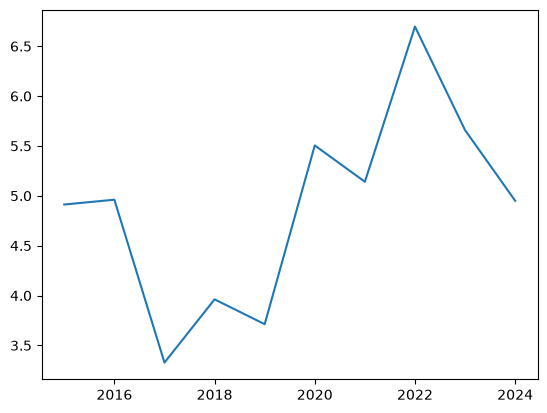

In [5]:
plt.plot(df['Year'], df['Average Inflation'])
plt.show()

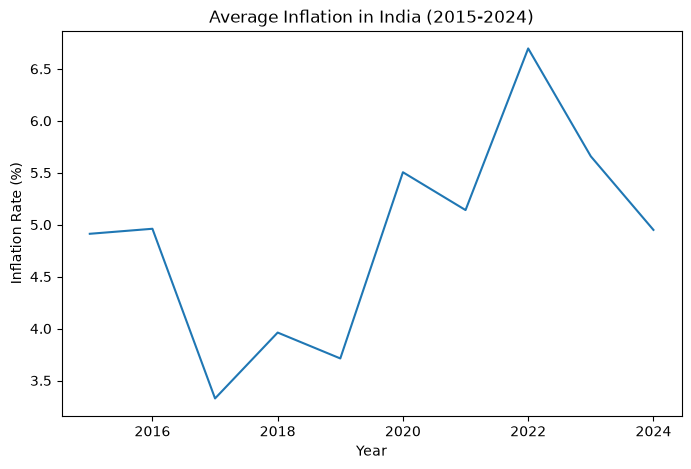

In [6]:
plt.figure(figsize=(8,5))

plt.plot(df['Year'], df['Average Inflation']
        )

plt.title('Average Inflation in India (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')

plt.savefig('../images_charts/inflation_trend.png')

plt.show()

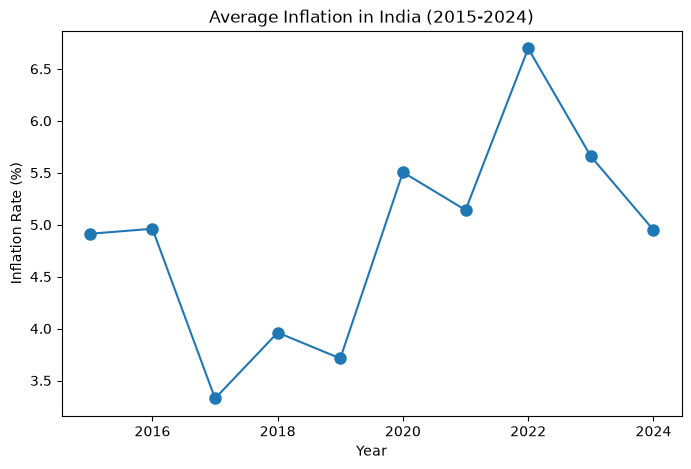

In [7]:
plt.figure(figsize=(8,5))

plt.plot(df['Year'], df['Average Inflation'], marker='o', markersize=8)

plt.title('Average Inflation in India (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')

plt.show()

In [8]:
df.loc[df['Average Inflation'].idxmax()]

Year                 2022.000000
Average Inflation       6.696667
Name: 7, dtype: float64

In [9]:
df.loc[df['Average Inflation'].idxmin()]

Year                 2017.0000
Average Inflation       3.3275
Name: 2, dtype: float64

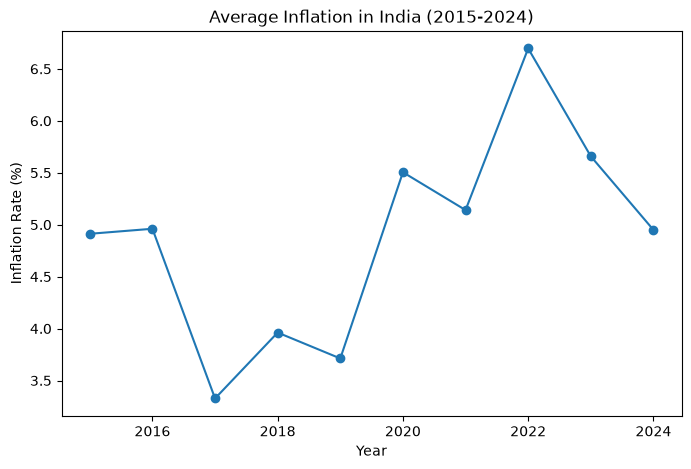

In [10]:
plt.figure(figsize=(8,5))

plt.plot(df['Year'], df['Average Inflation'], 'o-')

plt.title('Average Inflation in India (2015-2024)')
plt.xlabel('Year')
plt.ylabel('Inflation Rate (%)')

plt.savefig('../images_charts/inflation_trend.png')

plt.show()

In [11]:
df['Inflation Change'] = df['Average Inflation'].diff()
df.head(10)

,Year,Average Inflation,Inflation Change
0,2015,4.912500,NaN
1,2016,4.960833,0.048333
2,2017,3.327500,-1.633333
3,2018,3.961667,0.634167
4,2019,3.712500,-0.249167
5,2020,5.505000,1.792500
6,2021,5.140833,-0.364167
7,2022,6.696667,1.555833
8,2023,5.658333,-1.038333
9,2024,4.950000,-0.708333


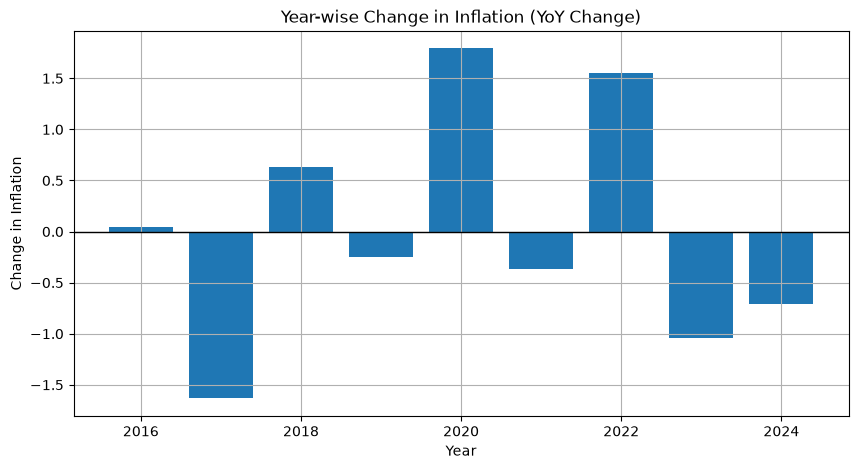

In [12]:
df_sorted = df.sort_values("Year")

df_sorted["Inflation Change"] = df_sorted["Average Inflation"].diff()

plt.figure(figsize=(10,5))

plt.bar(df_sorted["Year"], df_sorted["Inflation Change"])

plt.title("Year-wise Change in Inflation (YoY Change)")
plt.xlabel("Year")
plt.ylabel("Change in Inflation")

plt.axhline(0, color='black', linewidth=1)
plt.grid(True)

plt.show()

In [13]:
# Food vs Fuel Analysis  


In [16]:
import pandas as pd
food = pd.read_excel("../data/Food_Overall.xlsx")
fuel = pd.read_excel("../data/Fuel_2015_2024.xlsx")

food.head(), fuel.head()

(   baseyear  year  month_code      month      state    sector  \
 0      2012  2024          12   December  All India  Combined   
 1      2012  2024          11   November  All India  Combined   
 2      2012  2024          10    October  All India  Combined   
 3      2012  2024           9  September  All India  Combined   
 4      2012  2024           8     August  All India  Combined   
 
                 group                    subgroup  index  inflation status  
 0  Food and Beverages  Food and Beverages-Overall  205.9       7.69      F  
 1  Food and Beverages  Food and Beverages-Overall  208.4       8.20      F  
 2  Food and Beverages  Food and Beverages-Overall  209.4       9.69      F  
 3  Food and Beverages  Food and Beverages-Overall  204.8       8.36      F  
 4  Food and Beverages  Food and Beverages-Overall  202.7       5.30      F  ,
    baseyear  year  month_code      month      state    sector           group  \
 0      2012  2024          12   December  All Indi

In [20]:
food_clean = food[['year', 'inflation']]
fuel_clean = fuel[['year', 'inflation']]

In [21]:
food_yearly = food_clean.groupby('year', as_index=False).mean()
fuel_yearly = fuel_clean.groupby('year', as_index=False).mean()

In [22]:
food_yearly = food_yearly.rename(columns={'inflation': 'Food Inflation'})
fuel_yearly = fuel_yearly.rename(columns={'inflation': 'Fuel Inflation'})

In [23]:
merged = pd.merge(food_yearly, fuel_yearly, on='year')
merged

,year,Food Inflation,Fuel Inflation
0,2015,5.283333,5.302500
1,2016,5.373333,3.337500
2,2017,1.822500,5.558333
3,2018,1.714167,6.993333
4,2019,3.574167,0.463333
5,2020,8.635000,3.242000
6,2021,3.689167,10.157500
7,2022,6.826667,10.025833
8,2023,6.569167,4.115833
9,2024,7.623333,-2.743333


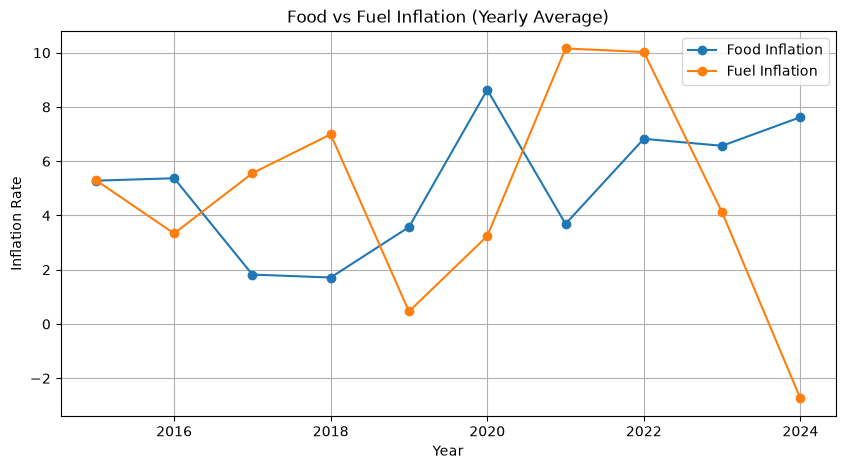

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(merged['year'], merged['Food Inflation'], marker='o', label='Food Inflation')
plt.plot(merged['year'], merged['Fuel Inflation'], marker='o', label='Fuel Inflation')

plt.title("Food vs Fuel Inflation (Yearly Average)")
plt.xlabel("Year")
plt.ylabel("Inflation Rate")

plt.legend()
plt.grid(True)

plt.show()

In [25]:
food_peak_year = merged.loc[merged['Food Inflation'].idxmax(), 'year']
food_peak_value = merged['Food Inflation'].max()

food_peak_year, food_peak_value

(np.int64(2020), np.float64(8.635))

In [26]:
fuel_peak_year = merged.loc[merged['Fuel Inflation'].idxmax(), 'year']
fuel_peak_value = merged['Fuel Inflation'].max()

fuel_peak_year, fuel_peak_value

(np.int64(2021), np.float64(10.1575))

In [27]:
merged[['Food Inflation', 'Fuel Inflation']].mean()

Food Inflation    5.111083
Fuel Inflation    4.645283
dtype: float64